# Reproduction: low-cost staining for *Bemisia tabaci* egg visualization

Reproduction of: **Van Raalte B, Prado J, Taddeo S, Mauck J (2024). "Evaluation of a low-cost staining method for improved visualization of sweet potato whitefly (*Bemisia tabaci*) eggs on multiple crop plant species." _Plant Methods_ 20:75.** DOI [10.1186/s13007-024-01209-z](https://doi.org/10.1186/s13007-024-01209-z) (CC BY 4.0).

**Scope (partial demonstration).** The paper stains/clears leaf discs and compares paired egg counts (two counters, before vs. after staining) in five crops. This notebook reproduces the **statistical core on the archived count data for Melon, Cowpea, and Tomato** — the crops covered by the authors' archived R script — by running the authors' own R code nearly verbatim and replicating their paired Wilcoxon signed-rank tests. The archived Zenodo record (11217925) does **not** include the separate cassava and sweet-potato analysis scripts that the paper's RMarkdown sources, so those two crops are out of scope here (this matches the paper's own code archive).

**Runtime:** CPU only — pure R statistics on small CSVs (<20 KB). No GPU is used or needed. Select **Runtime → Change runtime type → CPU**.

**日本語:** このノートブックは、論文の統計的中核（染色前後のペア卵数データの解析）を著者自身の R スクリプトで再現します。メロン・ササゲ・トマトの3作物が対象（アーカイブにカッサバ・サツマイモ用スクリプトは未収録）。CPU のみで実行できます。

| Paper operation (Rmd/script) | Notebook cell |
| --- | --- |
| Load Dryad count CSVs (`read.csv`) | §2: download + SHA-256 verify |
| `combining_crops_stainunstain_analysis.R` (Zenodo 11217925) | §3: run verbatim (paths only) |
| Paired Wilcoxon, `rstatix::wilcox_test(paired=TRUE)` | §4: per crop per counter |
| Figures 2/S1-style count & % difference plots | §5: display saved PNGs |

**Provenance:** author code = Zenodo record 11217925 (MIT license); data = Dryad doi:10.5061/dryad.vmcvdnd1m version 297485 (fetched at runtime from the Dryad API). Only edits to the authors' script: the six hard-coded local `read.csv` paths now point to `/content/data/`, and an appended driver saves/prints figures (`Rscript` does not auto-print ggplot objects). No scientific parameter is changed.

## 1. Setup: R runtime and packages

**Purpose / expected result.** The Colab Python runtime ships `Rscript`; we use Python only as a launcher for the authors' R analysis (per the verified CLI path for R code). This cell checks the R version and installs the exact packages the authors' script and tests use: `tidyr`, `dplyr`, `ggplot2`, `ggtext`, `ggsignif`, plus `rstatix` for the paired Wilcoxon tests. Expected: R ≥ 4.x and quiet package installs (~3–6 min on first run).

**日本語:** R 本体は Colab に同梱の `Rscript` を使用し、著者が使ったパッケージ(tidyr, dplyr, ggplot2, ggtext, ggsignif, rstatix)をインストールします。初回は数分かかります。

In [ ]:
import subprocess, textwrap
r = subprocess.run(["/usr/bin/Rscript", "-e",
    'cat(R.version.string, "\n"); ip <- rownames(installed.packages()); '
    'need <- setdiff(c("tidyr","dplyr","ggplot2","ggtext","ggsignif","rstatix"), ip); '
    'cat("missing:", paste(need, collapse=", "), "\n"); '
    'if (length(need)) install.packages(need, repos="https://cloud.r-project.org", quiet=TRUE); '
    'cat("installed:", paste(intersect(c("tidyr","dplyr","ggplot2","ggtext","ggsignif","rstatix"), rownames(installed.packages())), collapse=", "), "\n")'],
    capture_output=True, text=True, timeout=2400)
print(r.stdout[-2000:])
assert r.returncode == 0, r.stderr[-2000:]

R version 4.6.1 (2026-06-24) 
missing: ggtext, ggsignif, rstatix 
installed: tidyr, dplyr, ggplot2, ggtext, ggsignif, rstatix 



## 2. Data: download the archived egg-count CSVs (Dryad)

**Purpose / expected result.** Download the six egg-count CSVs used by the authors' script from the Dryad dataset **doi:10.5061/dryad.vmcvdnd1m, version 297485**, and verify each file's SHA-256 against the digests published in the public version file listing. Note: Dryad's per-file `/api/v2/files/{id}/download` endpoint currently rejects unauthenticated requests (HTTP 401, observed 2026-10-04), so this cell fetches the documented **version-pinned whole-dataset zip** (`/api/v2/versions/297485/download`, only 44.5 KB / 17 files) instead and extracts just the six needed CSVs into the author's repo-style subdirectories. Expected: 6 files, each matching its recorded digest, with a quick column/row summary.

**日本語:** 論文のカウント CSV 6件を Dryad のバージョン指定 ZIP (297485) から取得し、公開されている SHA-256 ダイジェストで検証します(ファイル単位のダウンロード API は現在 401 のため)。

In [ ]:
import json, urllib.request, hashlib, csv, io, os, zipfile

VER = "297485"
os.makedirs("/content/data", exist_ok=True)
# Public metadata listing: per-file sizes and SHA-256 digests (no bytes here).
with urllib.request.urlopen(
        f"https://datadryad.org/api/v2/versions/{VER}/files", timeout=120) as r:
    listing = json.load(r)
files = {f["path"]: f for f in listing["_embedded"]["stash:files"]}
# Per-file download endpoints require a bearer token (HTTP 401 observed 2026-10-04),
# so fetch the documented version-pinned dataset zip instead (44.5 KB, all 17 files)
# and extract only the six CSVs this reproduction needs.
url = f"https://datadryad.org/api/v2/versions/{VER}/download"
req = urllib.request.Request(url, headers={"User-Agent": "colab-repro/1.0"})
with urllib.request.urlopen(req, timeout=180) as r:
    zip_blob = r.read()
print(f"version {VER} zip: {len(zip_blob)} bytes, signature {zip_blob[:2]}")
assert zip_blob[:2] == b"PK", "not a zip"
zf = zipfile.ZipFile(io.BytesIO(zip_blob))
# Author-script read.csv paths expect this repo-style layout under the data root.
SUBDIR = {
    "egg_counts_instant_pot_test1.csv": "testing_instant_pot_rep1_09jun23/data",
    "egg_counts_instant_pot_test2.csv": "testing_instant_pot_rep2_30jun23/data",
    "egg_counts_stain_unstain_cowpea_rep4.csv": "cowpea_rep4_aug23",
    "egg_counts_stain_unstain_tgr_rep4-59do.csv": "tgr1551_rep4_59do_jul23",
    "egg_counts_stainunstain_tomato_rep2.csv": "tomato_rep2_aug23",
    "egg_re_count_tomato_rep2pt2.csv": "tomato_rep2pt2_aug23",
}
for name, subdir in SUBDIR.items():
    meta = files[name]
    blob = zf.read(name)
    digest = hashlib.sha256(blob).hexdigest()
    assert digest == meta["digest"], (name, digest, meta["digest"])
    d = f"/content/data/{subdir}"
    os.makedirs(d, exist_ok=True)
    with open(f"{d}/{name}", "wb") as f:
        f.write(blob)
    rows = list(csv.reader(io.StringIO(blob.decode("utf-8"))))
    print(f"{name}: {meta['size']} B, sha256 OK, {len(rows)-1} data rows, cols={rows[0]}")
print("All", len(SUBDIR), "CSVs verified against Dryad version", VER)

version 297485 zip: 44512 bytes, signature b'PK'
egg_counts_instant_pot_test1.csv: 2587 B, sha256 OK, 80 data rows, cols=['\ufeffleaf_num', 'species', 'stained', 'counter', 'count_date', 'egg_count', 'time_m', 'time_s']
egg_counts_instant_pot_test2.csv: 2475 B, sha256 OK, 64 data rows, cols=['\ufeffleaf_num', 'species', 'stained', 'clear_method', 'counter', 'count_date', 'egg_count', 'time_m', 'time_s']
egg_counts_stain_unstain_cowpea_rep4.csv: 2662 B, sha256 OK, 60 data rows, cols=['\ufeffleaf_num', 'species', 'stained', 'surfactant', 'counter', 'count_date', 'egg_count', 'time_m', 'time_s', 'bubbles', 'notes']
egg_counts_stain_unstain_tgr_rep4-59do.csv: 2490 B, sha256 OK, 60 data rows, cols=['\ufeffleaf_num', 'species', 'stained', 'surfactant', 'counter', 'count_date', 'egg_count', 'time_m', 'time_s', 'bubbles', 'bubbles_span80_0.5']
egg_counts_stainunstain_tomato_rep2.csv: 2545 B, sha256 OK, 64 data rows, cols=['\ufeffleaf_num', 'species', 'stained', 'surfactant', 'counter', 'count_

## 3. Run the authors' archived R analysis (Zenodo 11217925)

**Purpose / expected result.** This cell writes the authors' script `combining_crops_stainunstain_analysis.R` to `/content` and executes it with `Rscript`. The embedded script is **verbatim from Zenodo record 11217925** except: (a) the six hard-coded author-local paths are replaced by `/content/data/...`; (b) an appended driver saves the paper-relevant ggplots as PNGs and prints the summary tables (Rscript does not auto-print ggplot objects). No filters, parameters, or transformations were changed — including the authors' sample-exclusion subsets (instant-pot-1 leaves 1,3–6,16–20; instant-pot-2 leaves 1–8; cowpea ip1 leaves 21–25 & 36–40; one tomato pt1 disc). Expected: the three crop datasets are assembled, pivoted to paired wide form (`count_perdiff`, `avg_time_s`), summary stats per stain state are printed, and six PNG figures are saved.

**日本語:** 著者の R スクリプトを Zenodo 記録 11217925 からそのまま実行します。変更はファイルパス(`/content/data`)と、図の保存・要約表の print を追加するドライバ部のみです。著者によるサンプル除外条件もすべてそのまま適用されます。

In [ ]:
# The author's script (Zenodo record 11217925) is embedded base64-encoded below to
# avoid any quoting/escaping corruption. It is decoded and written verbatim (with the
# documented path + driver edits) to /content, then executed with Rscript.
import base64, subprocess
r_b64 = "..."
open("/content/author_script.R", "wb").write(base64.b64decode(r_b64))
print("author_script.R bytes:", len(base64.b64decode(r_b64)))
r = subprocess.run(["/usr/bin/Rscript", "/content/author_script.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
assert r.returncode == 0, r.stderr[-3000:]
if r.stderr.strip(): print("STDERR (tail):", r.stderr[-1500:])

author_script.R bytes: 18984



	Welch Two Sample t-test

data:  count_change by counter
t = -3.8285, df = 23.203, p-value = 0.0008501
alternative hypothesis: true difference in means between group one and group two is not equal to 0
95 percent confidence interval:
 -56.90576 -16.99424
sample estimates:
mean in group one mean in group two 
            18.95             55.90 

[[1]]
    x   y  colour PANEL group shape fill size alpha stroke
1   1   8 #F8766D     1     1    19   NA  1.5    NA    0.5
2   1   2 #39B600     1    10    19   NA  1.5    NA    0.5
3   1   7 #00BA38     1    11    19   NA  1.5    NA    0.5
4   1  37 #00BD5F     1    12    19   NA  1.5    NA    0.5
5   1  35 #00BF7D     1    13    19   NA  1.5    NA    0.5
6   1   3 #00C097     1    14    19   NA  1.5    NA    0.5
7   1  13 #00C0AF     1    15    19   NA  1.5    NA    0.5
8   1   4 #EF7F49     1     2    19   NA  1.5    NA    0.5
9   1  20 #E58700     1     3    19   NA  1.5    NA    0.5
10  1  14 #D89000     1     4    19   NA  1.5    NA    

## 4. Paired Wilcoxon signed-rank tests (per crop, per counter)

**Purpose / expected result.** Replicates the paper's statistical tests exactly as written in `results_outputs_v4.Rmd` (lines ~1014–1180): `rstatix::wilcox_test(..., paired = TRUE)` for `egg_count_one` (counter one, experienced, BVR), `egg_count_two` (counter two, novice, RL), and `count_perdiff` (absolute percent difference between counters), per crop. The paired wide frames are loaded from the RDS file saved by the §3 cell (each `Rscript` call is a fresh process). The paper reports (Table S2/S3 text): significant count increases for melon, tomato, cowpea for both counters (p < 0.001), and a significant drop in between-counter percent difference after staining. Expected here: matching directions and significance; V statistics and p-values are printed for direct comparison.

**日本語:** 論文と同じ `rstatix::wilcox_test(paired=TRUE)` を作物×カウンターごとに実行します。期待値: 染色後の卵数増加(3作物×両カウンターで p<0.001)と、カウンター間percent差の有意な減少。

In [ ]:
# The Wilcoxon test script is likewise embedded base64-encoded and run with Rscript.
import base64, subprocess
w_b64 = "CiMjIFBhaXJlZCB0d28tc2lkZWQgV2lsY294b24gc2lnbmVkLXJhbmsgdGVzdHMgcGVyIGNyb3AgcGVyIGNvdW50ZXIsCiMjIHJlcGxpY2F0aW5nIHJlc3VsdHNfb3V0cHV0c192NC5SbWQgKGxpbmVzIH4xMDE0LTExODApOiByc3RhdGl4Ojp3aWxjb3hfdGVzdCguLi4sIHBhaXJlZCA9IFRSVUUpCiMjIG9uIHRoZSAqX2NvbXBsZXRlX3N0YWluX3dpZGUgZnJhbWVzIGJ1aWx0IGJ5IHRoZSBhdXRob3IncyBzY3JpcHQuCiMjIFNjb3BlIG5vdGU6IHRoZSBhcmNoaXZlZCBaZW5vZG8gcmVjb3JkIGxhY2tzIHRoZSBjYXNzYXZhL3N3ZWV0LXBvdGF0byBhbmFseXNpcwojIyBzY3JpcHRzLCBzbyBvbmx5IE1lbG9uLCBDb3dwZWEsIFRvbWF0byBhcmUgdGVzdGVkIGhlcmUuCgpsaWJyYXJ5KHJzdGF0aXgpCmxpYnJhcnkoZHBseXIpICAgIyBiaW5kX3Jvd3Mvc2VsZWN0OyByc3RhdGl4IGRvZXMgbm90IHJlLWV4cG9ydCB0aGVzZQoKZnJhbWVzIDwtIHJlYWRSRFMoIi9jb250ZW50L2ZpZ3VyZXMvc3RhaW5fd2lkZV9mcmFtZXMucmRzIikKCnJ1bl9jcm9wIDwtIGZ1bmN0aW9uKGRmLCBzcGVjaWVzKSB7CiAgbGFwcGx5KGMoImVnZ19jb3VudF9vbmUiLCAiZWdnX2NvdW50X3R3byIsICJjb3VudF9wZXJkaWZmIiksCiAgICAgICAgIGZ1bmN0aW9uKHYpIHsKICAgICAgICAgICByc3RhdGl4Ojp3aWxjb3hfdGVzdChhcy5mb3JtdWxhKHBhc3RlKHYsICJ+IHN0YWluZWQiKSksIGRhdGEgPSBkZiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBwYWlyZWQgPSBUUlVFKSAlPiUKICAgICAgICAgICAgIG11dGF0ZShzcGVjaWVzID0gc3BlY2llcywgdmFyaWFibGUgPSB2LAogICAgICAgICAgICAgICAgICAgIHBfdmFsdWUgPSByb3VuZChwLCA2KSwgVl9zdGF0aXN0aWMgPSBzdGF0aXN0aWMpCiAgICAgICAgIH0pCn0KCnJlcyA8LSBiaW5kX3Jvd3MoCiAgcnVuX2Nyb3Aoc3Vic2V0KGZyYW1lcyRNZWxvbiwgIHNwZWNpZXMgPT0gIk1lbG9uIiksICAiTWVsb24iKSwKICBydW5fY3JvcChzdWJzZXQoZnJhbWVzJENvd3BlYSwgc3BlY2llcyA9PSAiQ293cGVhIiksICJDb3dwZWEiKSwKICBydW5fY3JvcChzdWJzZXQoZnJhbWVzJFRvbWF0bywgc3BlY2llcyA9PSAiVG9tYXRvIiksICJUb21hdG8iKSkKCnJlcyAlPiUgc2VsZWN0KHNwZWNpZXMsIHZhcmlhYmxlLCBWX3N0YXRpc3RpYywgcF92YWx1ZSkgJT4lIGFzLmRhdGEuZnJhbWUoKQoKd3JpdGUuY3N2KHJlcyAlPiUgc2VsZWN0KHNwZWNpZXMsIHZhcmlhYmxlLCBWX3N0YXRpc3RpYywgcF92YWx1ZSksCiAgICAgICAgICAiL2NvbnRlbnQvZmlndXJlcy93aWxjb3hvbl9yZXN1bHRzLmNzdiIsIHJvdy5uYW1lcyA9IEZBTFNFKQo="
open("/content/wilcoxon_tests.R", "wb").write(base64.b64decode(w_b64))
r = subprocess.run(["/usr/bin/Rscript", "/content/wilcoxon_tests.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
assert r.returncode == 0, r.stderr[-3000:]
import pandas as pd
pd.read_csv("/content/figures/wilcoxon_results.csv")

  species      variable V_statistic p_value
1   Melon egg_count_one         0.0 0.0e+00
2   Melon egg_count_two         0.0 0.0e+00
3   Melon count_perdiff       384.0 4.0e-06
4  Cowpea egg_count_one        10.5 8.6e-05
5  Cowpea egg_count_two         0.0 2.0e-06
6  Cowpea count_perdiff       205.0 1.9e-05
7  Tomato egg_count_one        38.5 1.3e-05
8  Tomato egg_count_two        18.5 0.0e+00
9  Tomato count_perdiff       425.0 1.6e-05



,species,variable,V_statistic,p_value
0,Melon,egg_count_one,0.0,0.000000
1,Melon,egg_count_two,0.0,0.000000
2,Melon,count_perdiff,384.0,0.000004
3,Cowpea,egg_count_one,10.5,0.000086
4,Cowpea,egg_count_two,0.0,0.000002
5,Cowpea,count_perdiff,205.0,0.000019
6,Tomato,egg_count_one,38.5,0.000013
7,Tomato,egg_count_two,18.5,0.000000
8,Tomato,count_perdiff,425.0,0.000016


## 5. Figures: paired counts and between-counter percent difference

**Purpose / expected result.** Displays the PNG figures saved by the authors' script: paired before→after egg counts per disc by counter (paper Figure 2–style), and boxplots of the between-counter percent difference before vs. after staining (paper Figure 3–style). Expected: after staining, counts shift upward and percent differences collapse toward 0 — visually matching the paper's figures.

**日本語:** 保存した図を表示します。染色後に卵数が増加し、カウンター間の相対差が0に近づくことが論文の図と同様に見えるはずです。

melon_counts_by_counter.png


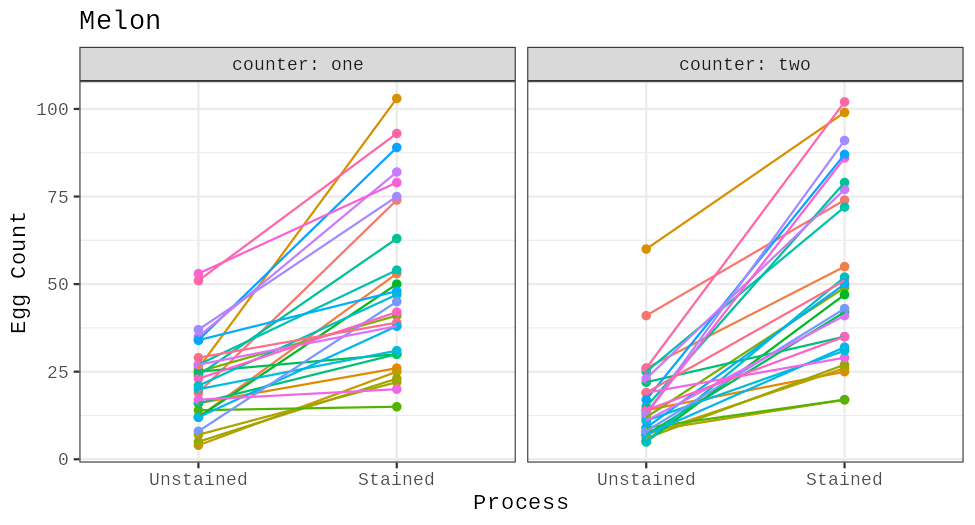

cowpea_counts_by_counter.png


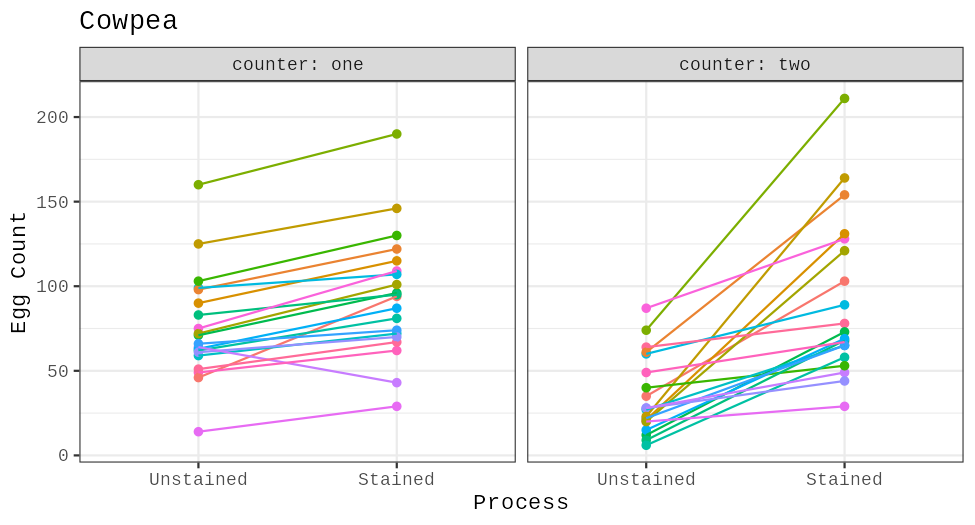

tomato_counts_by_counter.png


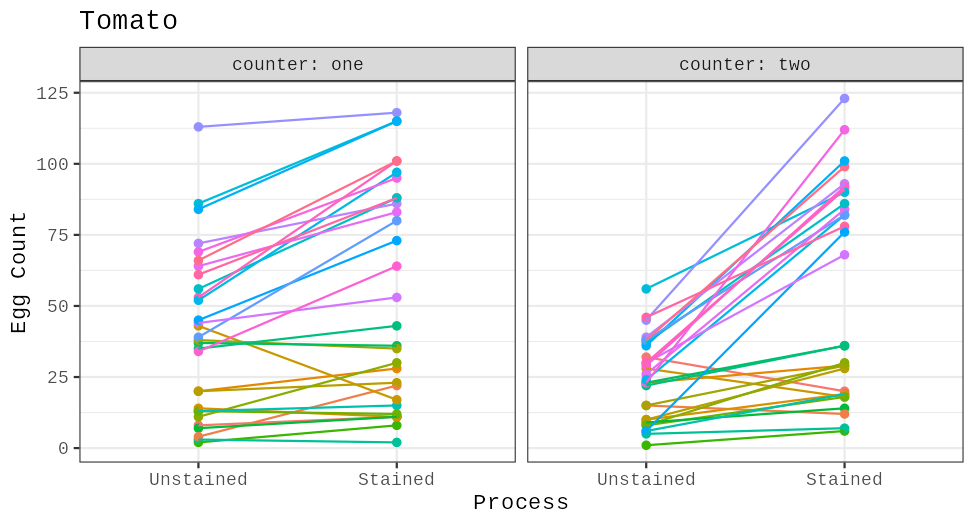

melon_perdiff.png


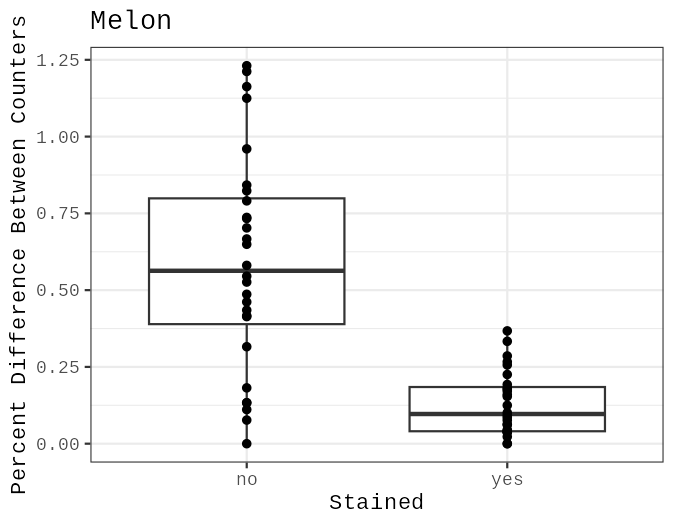

cowpea_perdiff.png


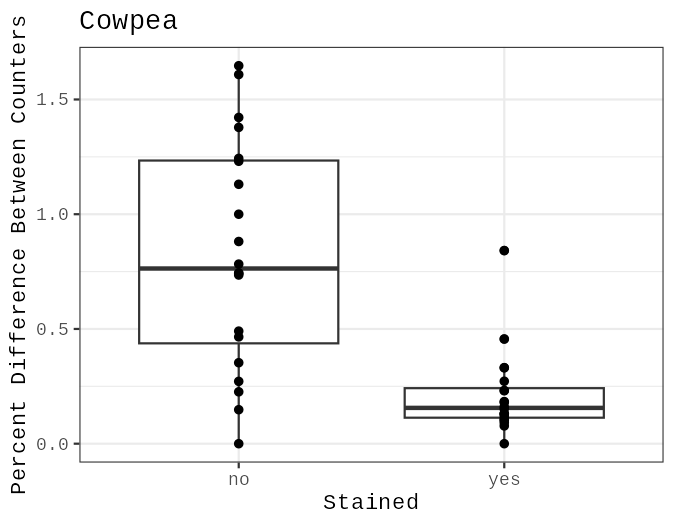

tomato_perdiff.png


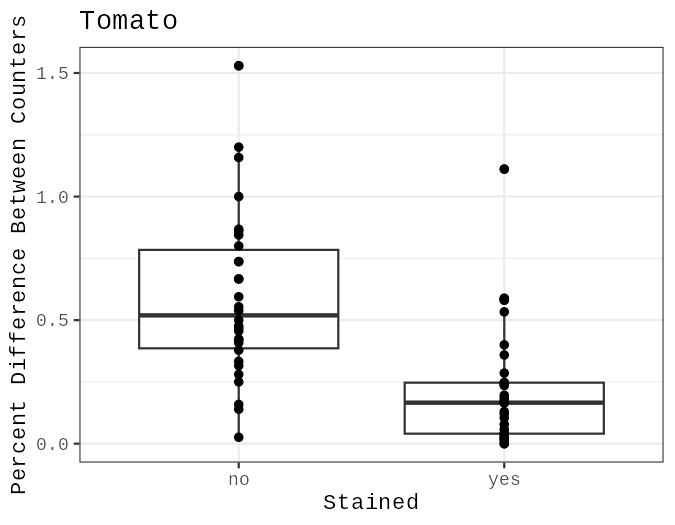

In [ ]:
from IPython.display import Image, display
for name in ["melon_counts_by_counter.png", "cowpea_counts_by_counter.png",
             "tomato_counts_by_counter.png", "melon_perdiff.png",
             "cowpea_perdiff.png", "tomato_perdiff.png"]:
    print(name)
    display(Image(filename=f"/content/figures/{name}", width=640))

## 6. Results vs. paper and limitations

**Expected comparison.** The Wilcoxon p-values/V statistics (cell 4) and the summary tables (cell 3) are compared with the paper's written statements and Tables S2–S3. Numerical results are deterministic (no randomness); only tiny deviations from the printed paper values are expected if the archived CSVs differ from the authors' working copies.

**Limitations.** (1) Three of five crops reproduced — the cassava and sweet-potato analysis scripts are not in the Zenodo archive. (2) Raw leaf-disc images are not deposited, so the image-based assessments are out of scope. (3) The authors' script edits paths only; all sample exclusions are kept as written.

**日本語:** 5作物のうち3作物を再現(アーカイブに残っていない2作物分のスクリプトのため)。結果は論文の Table S2/S3 および本文記載の統計量と比較してください。